# <font color=Blue>Unit 3 - Part 2: 零假设显著性检验 and t-检验</font>

updated on 2025-03-19

In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. 单样本z-检验 （总体方差$\sigma^2$已知, 正态分布）

检验样本均否来自均值为$\mu$的总体<br>
H0: 样本来自均值为$\mu$的总体<br>
H1: 样本不来自均值为$\mu$的总体

Step 1: 假定H0成立：<br>
Step 2: 那么样本均值的分布为$N(\mu,sem^2)$, 其中$sem=\frac{\sigma}{\sqrt{n}}$ <br>

Step 3: 计算观察到的样本均值ms的显著性水平p<br>

p=P(x>|ms||H0)+P(x<|ms||H0) <br>

Step 4: 检验p值， 如果很小，则认为样本与H0的兼容性差，可以拒绝零假设。



In [2]:
## One sample z-test, two-tailed

import numpy as np
import scipy.stats as stats

dSBP=np.array([3.5,5.2,-2.7,4.2,3.1,-2.8,3.9,3.2,4.3,-1.7,0.8,-0.9])


#检验dSBP是否等于mu

mu,sigma,ms,ns=0,3,np.mean(dSBP),len(dSBP)  # 总体均值，总体标准差， 样本均值,  样本大小

sem=sigma/np.sqrt(ns) # 样本均值的标准差  sem=sigma/sqrt(n)

p=stats.norm.cdf(mu-np.abs(mu-ms),mu,sem)+stats.norm.sf(mu+np.abs(mu-ms),mu,sem)  # 样本均值分布：

z=(np.mean(dSBP)-mu)/sem
print("(z,p)= ",z,p)

## 与t-test检验对比
print(stats.ttest_1samp(dSBP,mu))

(z,p)=  1.9341234017852467 0.05309795728558337
TtestResult(statistic=np.float64(1.961228058147819), pvalue=np.float64(0.07565581212405255), df=np.int64(11))


## 2. 单样本t-检验 （总体样本$\sigma^2$未知, t分布）

In [3]:
## One sample t-test, two-tailed  ## 检验血压药物是否改变血压
import numpy as np
import scipy.stats as stats
dSBP=np.array([3.5,5.2,-2.7,4.2,3.1,-2.8,3.9,3.2,4.3,-1.7,0.8,-0.9])
mu=0

t,p=stats.ttest_1samp(dSBP,0,alternative='two-sided')
print(t,p)

1.961228058147819 0.07565581212405255


### 课堂练习 (t-test-1)：2-tail/ 身高是否不同
如果全国初中男生的平均身高标准差165cm, 在上海某中学随机采样了12名男生，测得身高如下：
<br>
Subjects	1,	2,	3, 4,	5,	6,	7,	8,	9,	19,	11,	12
<br>
身高（cm)	170,172,162,160,175,157,168,167,172,165,179,162
<br>

这个中学的学生的男生平均身高与全国男生平均身高有差异？

In [4]:
## One sample t-test, two-tailed
height=np.array([170,172,162,160,175,157,168,167,172,165,179,162])
mu=164



## 3: 配对样本T-test

#### (1) function: stats.ttest_rel(a,b, altenative="two-sided") 
#### (2) it is equivalent to one-sample t-test
To test if the difference between two paired samples are significantly greater than a specified $\mu_0$ is: <br>
$t=\frac{\bar{x}-\mu_0}{s/\sqrt{n}}$ <br>
Given the confidence level of $\alpha$ (e.g. 0.05), the correpsonding <br>
$t_{\alpha/2,df}$=scipy.stats.norm.isf($\alpha/2$, df)


In [5]:
import numpy as np
import scipy.stats as stats
data1=np.array([7.1,8.2,8.5,9,8.2,6.7,6.3,6.4,7.2,8.5,9.2,6.8])
data2=np.array([5.3,5.9,6.0,7.2,7.2,6.5,6.0,4.5,5.1, 5.0,7.5,6.0])
t,p=stats.ttest_rel(data1,data2+2)
print("The T statistics is : ", t, " and the p-value is :", p)
if p<0.05: 
    print("The data1 is significantly different from data2")
else:
    print("The data1 is not significantly different from data2")

The T statistics is :  -1.2445037890170507  and the p-value is : 0.23917772036107388
The data1 is not significantly different from data2


## 4: 两个独立样本 t-检验
* function: stats.ttest_ind(data1,data2,equal_val="false", alternative="two-sided")

In [6]:
import numpy as np
import scipy.stats as stats
data1=np.array([7.1,8.2,8.5,9,8.2,6.7,6.3,6.4,7.2,8.5,9.2,6.8])
data2=np.array([5.3,5.9,6.0,7.2,7.2,6.5,6.0,4.5,5.1, 5.0,7.5,6.0])

t,p=stats.ttest_ind(data1,data2,equal_var="false")
print(t,p)

4.088247849534497 0.00048634399030309753


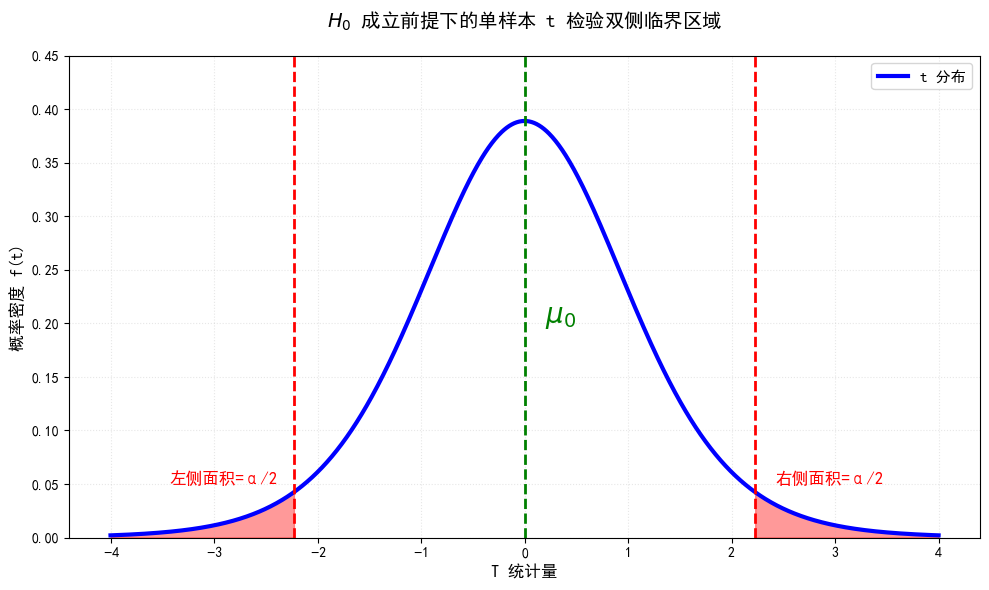

In [25]:
# 导入所需库
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]  

# -------------------------- 基础参数设置 --------------------------
df = 10          # 自由度 n-1
alpha = 0.05     # 显著性水平
alpha_half = alpha / 2  

# 计算双侧临界值
t_right = t.ppf(1 - alpha_half, df)  # 右侧临界值
t_left = -t_right                    # 左侧临界值（对称）

# -------------------------- 生成绘图数据 --------------------------
x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df)  

# -------------------------- 绘图 --------------------------
plt.figure(figsize=(10, 6), dpi=100)

# 绘制t分布曲线
plt.plot(x, y, 'b-', linewidth=3, label=f't 分布')

# 填充左侧 α/2 拒绝域
x_fill_left = np.linspace(-4, t_left, 200)
y_fill_left = t.pdf(x_fill_left, df)
plt.fill_between(x_fill_left, y_fill_left, color='red', alpha=0.4)

# 填充右侧 α/2 拒绝域
x_fill_right = np.linspace(t_right, 4, 200)
y_fill_right = t.pdf(x_fill_right, df)
plt.fill_between(x_fill_right, y_fill_right, color='red', alpha=0.4)

# 绘制双侧临界虚线
plt.axvline(t_left, color='red', linestyle='--', linewidth=2)
plt.axvline(t_right, color='red', linestyle='--', linewidth=2)
plt.axvline(0, color='green', linestyle='--', linewidth=2)
# -------------------------- 标注与文字 --------------------------
# 修复下标：使用 r'$LaTeX公式$' 语法，H₀下标正常显示
plt.title(r'$H_0$ 成立前提下的单样本 t 检验双侧临界区域', 
          fontsize=14, fontweight='bold', pad=20)

# 标注双侧 α/2
plt.text(t_left -1.2, 0.05, f'左侧面积=α/2', color='red', fontsize=12)
plt.text(t_right + 0.2, 0.05, f'右侧面积=α/2', color='red', fontsize=12)
plt.text(0.2,0.2, r'$\mu_0$', color='green', fontsize=20)

# 坐标轴与样式
plt.xlabel('T 统计量', fontsize=12)
plt.ylabel('概率密度 f(t)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3, linestyle=':')
plt.ylim(0, 0.45)

# 展示图像
plt.tight_layout()
plt.show()